<a href="https://www.kaggle.com/code/kidusassefamebrate/basic-exploratory-data-analysis-for-zomato?scriptVersionId=289677064" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # Data visualization
import seaborn as sbs
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/eda-on-zomato-dataset/zomato.csv
/kaggle/input/eda-on-zomato-dataset/Country-Code.xlsx


In [2]:
zo_df = pd.read_csv('/kaggle/input/eda-on-zomato-dataset/zomato.csv', encoding='ISO-8859-1')

## 1. Data Overview

In [3]:
zo_df

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,NamlÛ± Gurme,208,ÛÁstanbul,"Kemankeô Karamustafa Paôa Mahallesi, RÛ±htÛ±...",Karakí_y,"Karakí_y, ÛÁstanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz AÛôacÛ±,208,ÛÁstanbul,"Koôuyolu Mahallesi, Muhittin íìstí_ndaÛô Cadd...",Koôuyolu,"Koôuyolu, ÛÁstanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,Aôôk Kahve,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [4]:
zo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [5]:
zo_df = zo_df.drop(columns=[
    'Restaurant ID',
    'Address',
    'Locality',
    'Locality Verbose',
    'Longitude',
    'Latitude',
    'Currency',
    'Country Code',
    'Price range',
    'Rating color',
    'Rating text',
    'Is delivering now',
    'Switch to order menu',
    'Votes'
])


In [6]:
zo_df.head()

,Restaurant Name,City,Cuisines,Average Cost for two,Has Table booking,Has Online delivery,Aggregate rating
0,Le Petit Souffle,Makati City,"French, Japanese, Desserts",1100,Yes,No,4.8
1,Izakaya Kikufuji,Makati City,Japanese,1200,Yes,No,4.5
2,Heat - Edsa Shangri-La,Mandaluyong City,"Seafood, Asian, Filipino, Indian",4000,Yes,No,4.4
3,Ooma,Mandaluyong City,"Japanese, Sushi",1500,No,No,4.9
4,Sambo Kojin,Mandaluyong City,"Japanese, Korean",1500,Yes,No,4.8


### 1.1 Missing Values

In [7]:
zo_df.isnull().sum()

Restaurant Name         0
City                    0
Cuisines                9
Average Cost for two    0
Has Table booking       0
Has Online delivery     0
Aggregate rating        0
dtype: int64

In [8]:
zo_df['Cuisines']=zo_df['Cuisines'].fillna('Unknown')

In [9]:
zo_df.isnull().sum()

Restaurant Name         0
City                    0
Cuisines                0
Average Cost for two    0
Has Table booking       0
Has Online delivery     0
Aggregate rating        0
dtype: int64

## 2. Visualizations


### 2.1 Ratings by City

/tmp/ipykernel_17/2544301055.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sbs.barplot(x=filtered.values, y=filtered.index, palette="coolwarm")


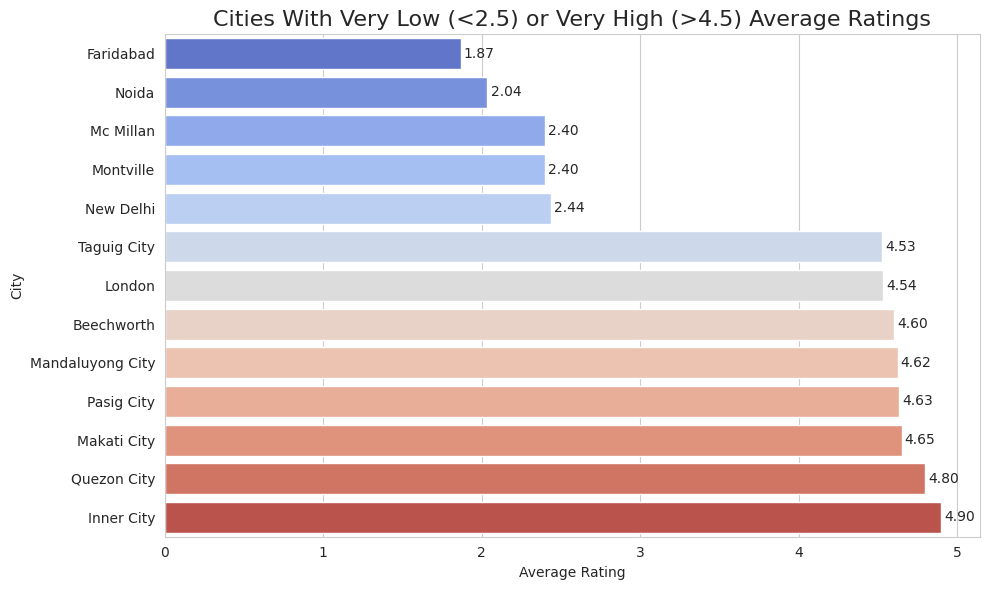

In [10]:
city_ratings = zo_df.groupby('City')['Aggregate rating'].mean()
filtered = city_ratings[(city_ratings < 2.5) | (city_ratings > 4.5)].sort_values()
plt.figure(figsize=(10, 6))
sbs.set_style("whitegrid")
sbs.barplot(x=filtered.values, y=filtered.index, palette="coolwarm")
plt.title("Cities With Very Low (<2.5) or Very High (>4.5) Average Ratings", fontsize=16)
plt.xlabel("Average Rating")
plt.ylabel("City")

for i, v in enumerate(filtered.values):
    plt.text(v + 0.02, i, f"{v:.2f}", va='center')

plt.tight_layout()
plt.show()


### 2.2 Cost vs Rating Scatterplot

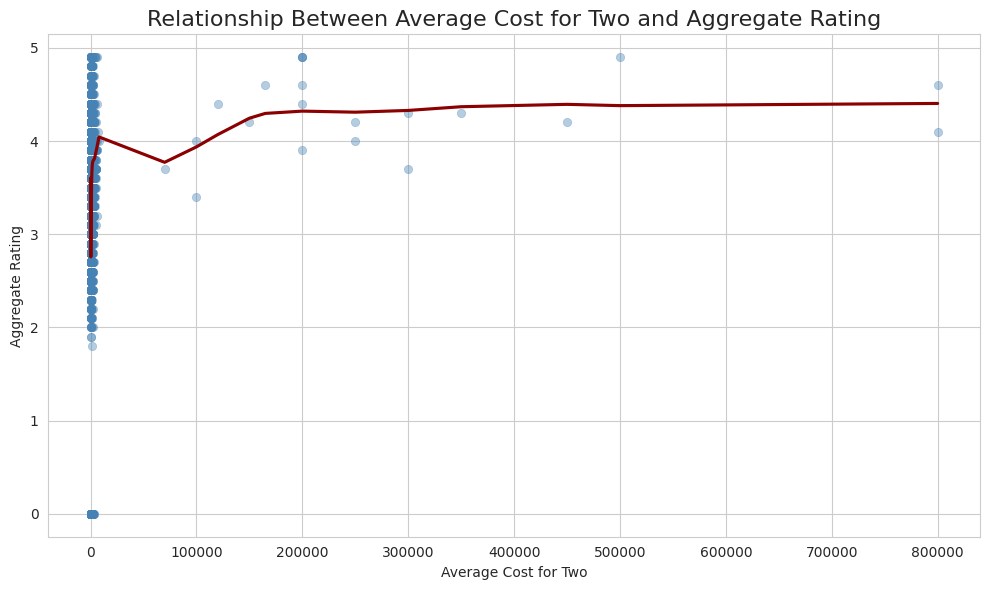

In [11]:
plt.figure(figsize=(10, 6))
sbs.set_style("whitegrid")
sbs.scatterplot(data=zo_df, x='Average Cost for two', y='Aggregate rating', alpha=0.4, color='steelblue', edgecolor=None)
sbs.regplot(data=zo_df, x='Average Cost for two', y='Aggregate rating', scatter=False, lowess=True, color='darkred')
plt.title("Relationship Between Average Cost for Two and Aggregate Rating", fontsize=16)
plt.xlabel("Average Cost for Two")
plt.ylabel("Aggregate Rating")
plt.tight_layout()
plt.show()


In [12]:
pivot = zo_df.pivot_table(values='Aggregate rating', index='City', columns=['Has Online delivery', 'Has Table booking'], aggfunc='mean')

In [13]:
pivot_clean = pivot.dropna()

In [14]:
pivot_clean

Has Online delivery        No                 Yes          
Has Table booking          No       Yes        No       Yes
City                                                       
Abu Dhabi            4.371429  4.800000  4.100000  4.275000
Bangalore            4.430000  4.133333  4.375000  4.433333
Chennai              4.520000  4.100000  4.000000  4.318182
Dubai                4.216667  4.600000  4.100000  4.275000
Faridabad            1.648039  2.066667  3.162500  2.133333
Ghaziabad            2.623077  2.550000  3.366667  1.800000
Gurgaon              1.977102  3.421642  3.216620  3.695714
Hyderabad            4.700000  4.100000  4.233333  4.350000
Kolkata              4.516667  4.033333  4.160000  4.333333
Mumbai               4.225000  3.760000  4.200000  4.125000
New Delhi            1.995909  3.302273  3.169357  3.540727
Noida                1.466411  2.743750  2.868671  3.352083
Pune                 4.400000  4.177778  4.266667  4.100000

### 2.3 Average Restaurant Ratings by City\nOnline Delivery × Table Booking

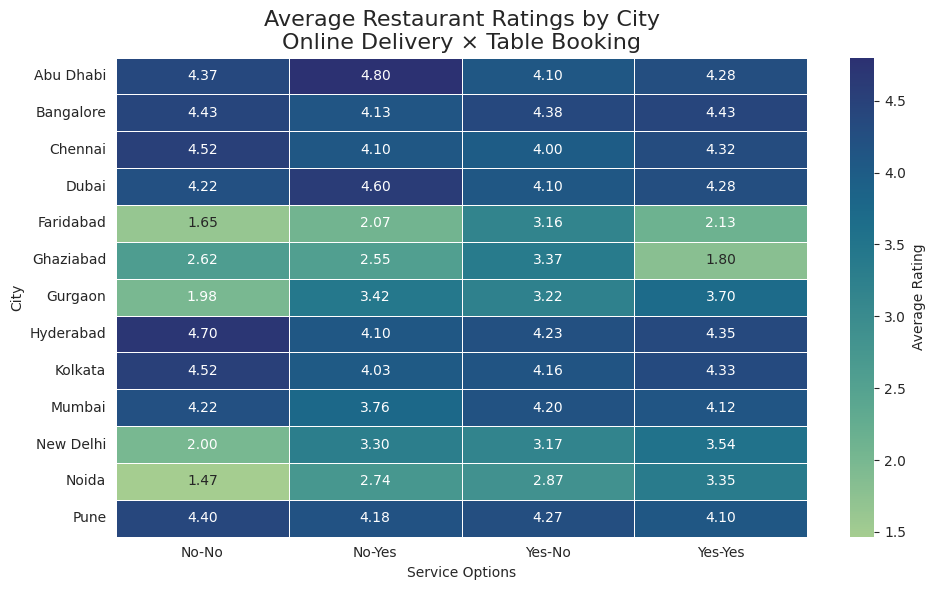

In [15]:
plt.figure(figsize=(10, 6))
sbs.heatmap(pivot_clean,annot=True,fmt=".2f", cmap="crest", linewidths=0.5, cbar_kws={'label': 'Average Rating'})
plt.title("Average Restaurant Ratings by City\nOnline Delivery × Table Booking", fontsize=16)
plt.xlabel("Service Options")
plt.ylabel("City")
plt.tight_layout()
plt.show()
